In [1]:
import sys
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F

# still do preprocessing in scipy
import scipy.sparse as sp

from importlib import reload

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/splicing-VAE')
import VAE_model
reload(VAE_model)

import matplotlib.pyplot as plt

<module 'VAE_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/splicing-VAE/VAE_model.py'>

In [2]:
# review https://sebastiancallh.github.io/post/vae-anatomy/

In [3]:
leaflet_repo = '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/'
sys.path.append(leaflet_repo)
import load_cluster_data
from betabinomo_mix_singlecells import *

### Settings and Load data

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


In [5]:
device

device(type='cpu')

In [6]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte'] #ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
7816
16190
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-M

In [7]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [8]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [9]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [10]:
# set up sparse tensor for junction counts 
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [11]:
# set up sparse tensor for cluster counts
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [12]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [13]:
# check if train_loader is on cuda
torch.cuda.is_available()

False

In [14]:
# Example usage:
junction_tensor, intron_tensor = y_tensor, total_counts_tensor

In [15]:
# input --> junction usage ratios (PSI)
# output --> junction counts via inferred PSI and total counts

In [83]:
reload(VAE_model)
from VAE_model import *

In [96]:
# Configuration
LEARNING_RATE = 0.001
NUM_EPOCHS = 15
BATCH_SIZE = 256
USE_CUDA = torch.cuda.is_available()
print(USE_CUDA)

INPUT_DIM = junction_tensor.shape[1]
HIDDEN_DIMS = [128, 64, 32]  # Example dimensions, adjust as needed
Z_DIM = 20
OUTPUT_DIM = INPUT_DIM  # Assuming output dimension matches input
perc_train = 0.7

False


In [97]:
train_loader, test_loader, full_dat = setup_data_loaders(junction_tensor, intron_tensor, BATCH_SIZE, USE_CUDA, perc_train)

model = VAE(INPUT_DIM, HIDDEN_DIMS, Z_DIM, OUTPUT_DIM)
model.train()

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

Percentage of data used for training:  0.7


In [98]:
# best validation loss 
best_val_loss = float('inf')
max_patience = 2
best_epoch = 0
train_losses = []
val_losses = []

# Training Loop
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}")
    avg_train_loss = train(model, train_loader, optimizer, epoch)
    avg_val_loss = evaluate(model, test_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        patience = max_patience
    else:
        patience -= 1
        if patience == 0:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 1


====> Epoch: 1 Average training loss: 1.0422
====> Evaluation set average loss: 0.1822
Epoch 2
====> Epoch: 2 Average training loss: 0.2253
====> Evaluation set average loss: 0.0595
Epoch 3
====> Epoch: 3 Average training loss: 0.1088
====> Evaluation set average loss: 0.0363
Epoch 4
====> Epoch: 4 Average training loss: 0.0775
====> Evaluation set average loss: 0.0267
Epoch 5
====> Epoch: 5 Average training loss: 0.0584
====> Evaluation set average loss: 0.0209
Epoch 6
====> Epoch: 6 Average training loss: 0.0474
====> Evaluation set average loss: 0.0173
Epoch 7
====> Epoch: 7 Average training loss: 0.0393
====> Evaluation set average loss: 0.0150
Epoch 8
====> Epoch: 8 Average training loss: 0.0323
====> Evaluation set average loss: 0.0133
Epoch 9
====> Epoch: 9 Average training loss: 0.0279
====> Evaluation set average loss: 0.0123
Epoch 10
====> Epoch: 10 Average training loss: 0.0238
====> Evaluation set average loss: 0.0114
Epoch 11
====> Epoch: 11 Average training loss: 0.0213
=

In [99]:
# why is it when i increase latent space z dim, the validation loss is smaller than training loss?
# if i keep it at 20, the training loss is smaller than validation loss which is expected

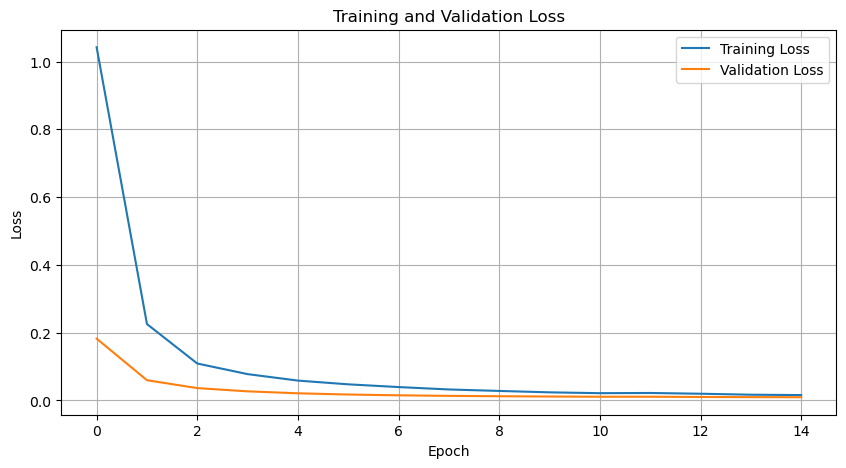

In [100]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [101]:
reload(VAE_model)
from VAE_model import *

In [102]:
model.eval()  # Set the model to evaluation mode
latent_variables = []
with torch.no_grad():
    for data in full_dat:
        inputs = data['proportions'].to(device)  # Ensure data is on the correct device
        z = model.extract_latent_variables(inputs, apply_noise=False)  # Apply_noise=False to get the mean of the latent space
        latent_variables.append(z.cpu().numpy())  # Move z to CPU and convert to numpy

latent_variables = np.concatenate(latent_variables, axis=0)

Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False


In [103]:
import umap

reducer = umap.UMAP(random_state=42)
umap_embedding = reducer.fit_transform(latent_variables)

In [104]:
latent_variables_df = pd.DataFrame(latent_variables)
latent_variables_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.009057,0.018157,-0.008227,0.002274,-0.004674,0.011089,-0.008600,-0.005523,-0.000873,0.000650,-0.002752,-0.000069,-0.003065,-0.004764,-0.000838,0.007201,0.004826,0.009993,0.002481,0.004518
1,0.003129,0.013513,-0.010506,0.002245,-0.012896,0.004303,0.003255,-0.012605,0.002797,0.003976,-0.005692,0.005056,-0.003677,-0.000473,0.003519,0.008603,0.002433,0.006385,0.001852,0.003835
2,0.005576,0.010042,-0.003773,0.002192,-0.010830,0.000258,0.005018,0.001948,-0.003076,0.000897,0.004234,0.006360,-0.002703,0.000493,0.002789,-0.002608,0.003283,0.001005,0.007889,0.004963
3,0.010063,0.002744,-0.003287,-0.002211,-0.003991,0.010023,-0.006324,-0.005173,0.000724,-0.001031,-0.010543,0.003080,-0.004762,-0.000342,-0.004361,0.010908,-0.000859,-0.006207,-0.006904,-0.009857
4,0.001983,0.012796,-0.011847,0.005598,-0.011448,0.007382,-0.012963,-0.004840,0.003212,0.006257,0.000806,-0.003448,0.001534,-0.003472,0.002946,0.002817,0.003120,0.007356,-0.001145,0.006092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7811,-0.001607,0.000912,-0.005912,-0.001713,0.004983,0.002964,-0.007069,0.002551,-0.005459,-0.009757,-0.003244,0.000208,-0.004770,-0.005781,-0.003350,-0.002670,-0.005616,-0.011910,-0.001756,-0.003140
7812,0.001173,0.000863,-0.002583,-0.000425,0.003033,-0.000896,-0.000316,0.000594,-0.000261,-0.002605,0.000079,0.001651,-0.002236,-0.000300,-0.001320,-0.000904,-0.006821,-0.000069,-0.002204,0.001349
7813,0.001928,-0.002183,-0.000661,-0.001133,-0.000509,-0.002565,0.000662,0.005168,0.001590,-0.002078,-0.000912,0.001451,-0.001381,0.000246,-0.003690,-0.005277,-0.002348,-0.001193,0.001406,0.000774
7814,-0.010218,-0.007529,0.002675,0.009229,0.006986,-0.008238,0.011806,0.001057,-0.019576,0.002951,-0.025808,0.031009,0.005897,0.001951,0.008591,-0.009348,0.000544,0.009274,-0.003935,0.018708


In [105]:
umap_embedding_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])
umap_embedding_df["cell_type"] = cell_ids_conversion["cell_type"].values
umap_embedding_df.head()

,UMAP1,UMAP2,cell_type
0,-1.780377,2.773896,Brain_Non-Myeloid_brain_pericyte
1,-1.753146,2.818798,Brain_Non-Myeloid_brain_pericyte
2,-2.508995,5.774134,Brain_Non-Myeloid_brain_pericyte
3,-2.858689,10.451764,Brain_Non-Myeloid_brain_pericyte
4,-2.040394,2.477099,Brain_Non-Myeloid_brain_pericyte


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

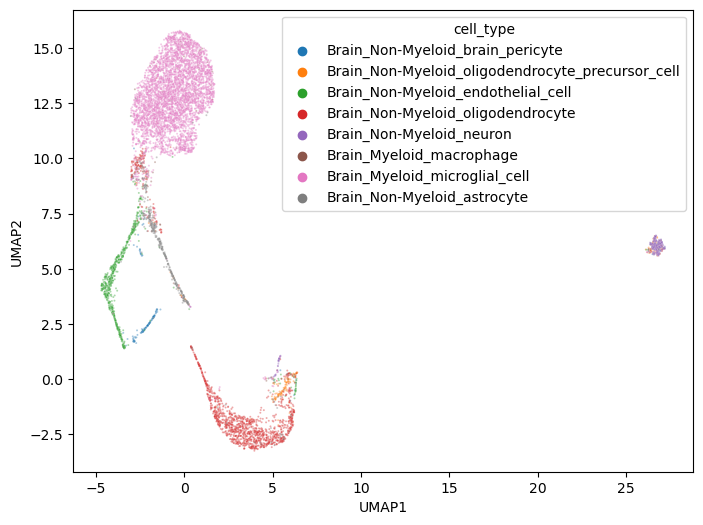

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=umap_embedding_df, x='UMAP1', y='UMAP2', hue='cell_type', palette='tab10', s=2, alpha=0.4)